# Third-Party Data Sharing Classification

We aim to classify whether an app’s privacy policy mentions sharing data with third parties.

**Dataset Used:** [MAPP Corpus (LREC 2022)](https://usableprivacy.org/data) by [Arora et al. (2022)](https://usableprivacy.org/static/files/Arora_LREC_2022.pdf)

**Data preprocessing steps** included lemmatization, stopword removal, normalization, tokenization, and TF-IDF vectorization of the policy text.

**Research Question:** Does the app share data with third parties?

To address this, we merged the categories `['Third Party']` and`['First Party','Third Party']` into a single **“Third Party”** class, converting the problem into a binary classification task:  
- **Label 0** = No Third Party  
- **Label 1** = Third Party  

We trained multiple models to identify the best approach for detecting third-party data sharing:  
- **Logistic Regression**: reliable baseline for sparse text features  
- **Random Forest**: captures diverse language patterns  
- **SVC**: effective for high-dimensional feature spaces  
- **XGBoost**: handles complex and subtle policy language  
- **Balanced Random Forest**: addresses class imbalance for improved fairness  

The results will help determine which model best classifies third-party data sharing mentions in privacy policies.


###   Import Libraries

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import shutil
import os
import chardet
import re
from tqdm import tqdm  # Import tqdm for the progress bar
from tqdm.auto import tqdm
tqdm.pandas()
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle #save jobs
import joblib #save models
from collections import Counter
!pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import ast
import sys
import time
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain
from pathlib import Path
from wordcloud import WordCloud

from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
!pip install transformers datasets scikit-learn tqdm joblib --quiet

import torch
from transformers import BertTokenizerFast, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import random
import random
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
from tqdm import tqdm
import time
import joblib
import pandas as pd

from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.base import clone
from tqdm import tqdm
import numpy as np

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


### Preprocessing

In [3]:
# Paths to data folders
annotations_dir = '/content/drive/MyDrive/Colab Notebooks/Project/English_consolidation/'
texts_dir = '/content/drive/MyDrive/Colab Notebooks/Project/English_sanitized_policies/'


# List .csv or .tsv files in the annotations_dir
csv_files = [f for f in os.listdir(annotations_dir) if f.endswith(('.csv', '.tsv'))]

sample_csv = pd.read_csv(os.path.join(annotations_dir, csv_files[0]), sep='\t', engine='python')
print(sample_csv.columns.tolist())


['policy id,segment_id,category name,attribute name,value name,policy_type,privacy_policy_link,MAPP_59']


In [4]:
# Create an empty list to store all DataFrames
all_dfs = []

# Loop through each CSV and match its TXT
for csv_file in tqdm(csv_files, desc="Processing files"):
    csv_path = os.path.join(annotations_dir, csv_file)
    txt_file = csv_file.replace('.csv', '.txt')
    txt_path = os.path.join(texts_dir, txt_file)

    # Check if the matching text file exists
    if not os.path.exists(txt_path):
        print(f"Text file missing for: {csv_file}")
        continue

    # Load CSV
    df = pd.read_csv(csv_path, sep=',', engine='python')
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_') # normalize column headers

    # Read and segment the text file (split by double newlines)
    with open(txt_path, 'r', encoding='utf-8') as f:
        text = f.read()
        segments = [seg.strip() for seg in text.replace('\r\n', '\n').replace('\r', '\n').split('\n\n') if seg.strip()]

    # Map segment text to DataFrame
    df['segment_text'] = df['segment_id'].apply(
        lambda x: segments[x - 1] if 1 <= x <= len(segments) else ""
    )

    # Add filename as an identifier
    df['source_file'] = csv_file

    # Append
    all_dfs.append(df)

# Combine all into one DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)


print("n/All files processed. Final DataFrame shape:", final_df.shape)

final_df.info()

Processing files: 100%|██████████| 64/64 [00:38<00:00,  1.68it/s]

n/All files processed. Final DataFrame shape: (3976, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3976 entries, 0 to 3975
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   policy_id            3976 non-null   int64 
 1   segment_id           3976 non-null   int64 
 2   category_name        3976 non-null   object
 3   attribute_name       3976 non-null   object
 4   value_name           3976 non-null   object
 5   policy_type          3976 non-null   object
 6   privacy_policy_link  3976 non-null   object
 7   mapp_59              3976 non-null   bool  
 8   segment_text         3976 non-null   object
 9   source_file          3976 non-null   object
dtypes: bool(1), int64(2), object(7)
memory usage: 283.6+ KB


In [5]:
# Save merged data
final_df.to_csv("mapp_preprocessed_dataset2.csv", index=False)

# Check data
print("Unique policies:", final_df['policy_id'].nunique())

missing_segments = final_df[final_df['segment_text'].isnull()]
print("Total missing segments:", len(missing_segments))

duplicates =  final_df[final_df.duplicated(subset=['policy_id', 'segment_id', 'category_name', 'attribute_name', 'segment_text'], keep=False)]
print("Total duplicates:", len(duplicates))

text_files = [f for f in os.listdir(texts_dir) if f.endswith('.txt')]

total_segments = 0

for txt_file in sorted(text_files):
    with open(os.path.join(texts_dir, txt_file), 'r', encoding='utf-8') as f:
        text = f.read()
        segments = [seg.strip() for seg in re.split(r'\n\s*\n', text) if seg.strip()]
        num_segments = len(segments)
        total_segments += num_segments

print(f" Total segments across all TXT files: {total_segments}")

Unique policies: 64
Total missing segments: 0
Total duplicates: 0
 Total segments across all TXT files: 3976


In [6]:
combined_df = final_df.copy()

#Text Preprocessing
#Clean up text by removing noise, lowercasing, and tokenizing for better NLP results.

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    tokens = word_tokenize(text)   # Tokenize
    tokens = [word for word in tokens if word not in stopwords.words('english')] # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize

    return " ".join(tokens)


# Show progress
tqdm.pandas()

# Apply the preprocess_text function with a progress bar
combined_df['clean_text'] = combined_df['segment_text'].progress_apply(preprocess_text)

100%|██████████| 3976/3976 [00:51<00:00, 77.09it/s] 


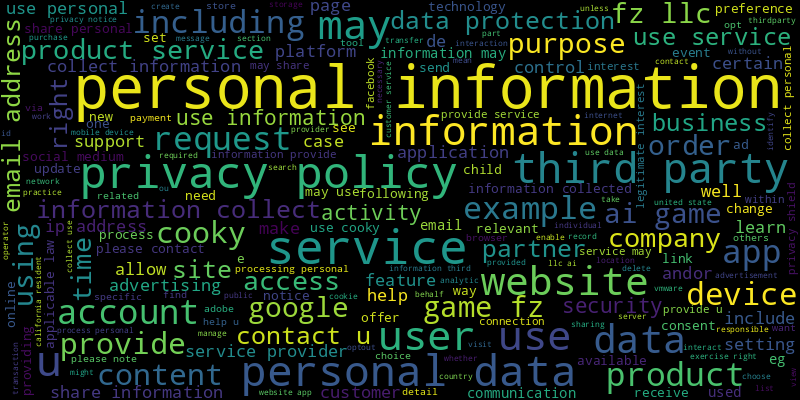

In [7]:
text = " ".join(combined_df['clean_text'])
WordCloud(width=800, height=400).generate(text).to_image()

## Category Classification
*   Does the App share data with Third Parties?




In [8]:
# View distribution
original_counts = combined_df['category_name'].value_counts()
original_counts

,count
category_name,
[],2409
['First Party'],1023
['Third Party'],365
"['First Party', 'Third Party']",179


In [9]:
# Drop empty labels
cat_df = combined_df[combined_df['category_name'].str.strip() != '[]']
filtered_counts = cat_df['category_name'].value_counts()
filtered_counts

,count
category_name,
['First Party'],1023
['Third Party'],365
"['First Party', 'Third Party']",179


In [21]:
#Binary Classification — “Shares Data With Third Parties?”
#1 = mentions sharing with third parties (has "Third Party" in list)
#0 = doesn't mention third parties (either "First Party" or empty)

cat_df['label'] = cat_df['category_name'].apply(lambda x: 1 if 'Third Party' in x else 0)
binary_counts = cat_df['label'].value_counts()
binary_counts.index = ['No Third Party (0)', 'Third Party (1)']

binary_counts

,count
No Third Party (0),1023
Third Party (1),544


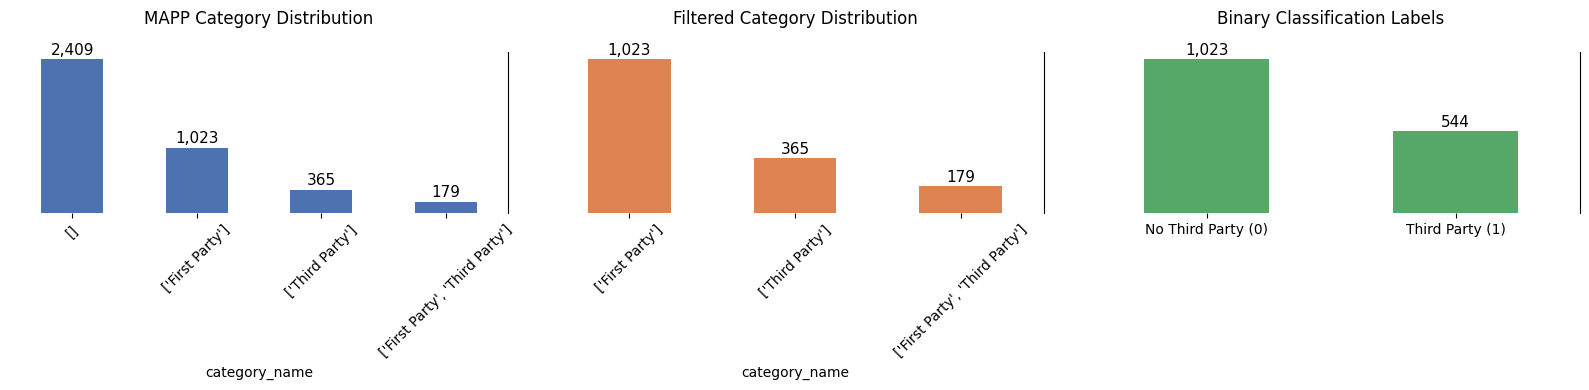

In [ ]:
# seaborn deep color palette
colors = sns.color_palette('deep')[:3]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# annotate bars for visibility
def annotate_bars(ax, counts):
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.01, f"{v:,}", ha='center', va='bottom',
        fontsize=11, color='black')

# remove spines (box edges)
def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

# first: Original category
original_counts.plot(kind='bar', ax=axes[0], color=colors[0])
axes[0].set_title("MAPP Category Distribution", pad=20)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("")
axes[0].set_yticks([])
annotate_bars(axes[0], original_counts)
clean_spines(axes[0])

# second: Filtered category
filtered_counts.plot(kind='bar', ax=axes[1], color=colors[1])
axes[1].set_title("Filtered Category Distribution", pad=20)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("")
axes[1].set_yticks([])
annotate_bars(axes[1], filtered_counts)
clean_spines(axes[1])

# third: Binary labels
binary_counts.plot(kind='bar', ax=axes[2], color=colors[2])
axes[2].set_title("Binary Classification Labels",pad=20)
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_ylabel("")
axes[2].set_yticks([])
annotate_bars(axes[2], binary_counts)
clean_spines(axes[2])

# layout and save
plt.tight_layout()
plt.savefig("category_distributions.png", dpi=300, bbox_inches='tight')
plt.show()


In [39]:
# Initialize classifiers with class balance
classifiers = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced_subsample', n_estimators=100, random_state=42),
    "SVC": SVC(kernel='linear', C=1.0, random_state=42, class_weight='balanced', probability=True),
    "XGBoost": XGBClassifier(scale_pos_weight=5, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Balanced RF": BalancedRandomForestClassifier(n_estimators=100, random_state=42)
}

X = cat_df['clean_text']
y = cat_df['label']

# Vectorize
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=2, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

joblib.dump(vectorizer, 'tfidf_vectorizer_cat.pkl')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
results = []
confusion_matrices = []
predictions = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    # handle SVC: scale input (TF-IDF is sparse, with_mean=False)
    if name == "SVC":
        scaler = StandardScaler(with_mean=False)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        clf.fit(X_train_scaled, y_train)
    else:
        clf.fit(X_train, y_train)

    # Progress bar (simulated delay)
    with tqdm(total=X_train.shape[0], desc=f"{name} - Training", unit="data") as pbar:
        for _ in range(X_train.shape[0]):
            time.sleep(0.001)
            pbar.update(1)

    # Save model
    joblib.dump(clf, f'{name.replace(" ", "_").lower()}_model.pkl')

    # Predictions
    y_pred_test = clf.predict(X_test_scaled if name == "SVC" else X_test)
    y_pred_train = clf.predict(X_train_scaled if name == "SVC" else X_train)
    predictions[name] = y_pred_test

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    cm_df = pd.DataFrame(cm, index=['Actual No Third Party', 'Actual Third Party'],
                              columns=['Predicted No Third Party', 'Predicted Third Party'])
    confusion_matrices.append((name, cm_df))

    # Metrics
    accuracy_test = accuracy_score(y_test, y_pred_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    report = classification_report(y_test, y_pred_test,
                                   target_names=['No Third Party', 'Third Party'],
                                   output_dict=True)

    precision_0 = report['No Third Party']['precision']
    recall_0 = report['No Third Party']['recall']
    f1_0 = report['No Third Party']['f1-score']

    precision_1 = report['Third Party']['precision']
    recall_1 = report['Third Party']['recall']
    f1_1 = report['Third Party']['f1-score']

    # AUC-ROC
    if hasattr(clf, "predict_proba"):
        y_pred_prob = clf.predict_proba(X_test_scaled if name == "SVC" else X_test)[:, 1]
    else:  # fallback for classifiers without predict_proba (like SVC without probability=True)
        y_pred_prob = clf.decision_function(X_test_scaled if name == "SVC" else X_test)
    auc_roc = roc_auc_score(y_test, y_pred_prob)

    # Append results
    results.append({
        'Classifier': name,
        'Precision (0)': precision_0,
        'Recall (0)': recall_0,
        'F1 Score (0)': f1_0,
        'Precision (1)': precision_1,
        'Recall (1)': recall_1,
        'F1 Score (1)': f1_1,
        'AUC-ROC': auc_roc,
        'Accuracy on Test Set': accuracy_test,
        'Accuracy on Train Set': accuracy_train
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
summary_cm_df = pd.concat([cm for name, cm in confusion_matrices], keys=[name for name, _ in confusion_matrices])


Training Logistic Regression...


Logistic Regression - Training: 100%|██████████| 1253/1253 [00:01<00:00, 906.86data/s]



Training Random Forest...


Random Forest - Training: 100%|██████████| 1253/1253 [00:01<00:00, 908.79data/s]



Training SVC...


SVC - Training: 100%|██████████| 1253/1253 [00:01<00:00, 874.26data/s]



Training XGBoost...


XGBoost - Training: 100%|██████████| 1253/1253 [00:01<00:00, 912.79data/s]



Training Balanced RF...


Balanced RF - Training: 100%|██████████| 1253/1253 [00:01<00:00, 915.90data/s]


In [46]:
# Round all numeric values to 2 decimal places before saving
results_df.round(2).to_excel('all_models_results_df.xlsx', index=False)
results_df

,Classifier,Precision (0),Recall (0),F1 Score (0),Precision (1),Recall (1),F1 Score (1),AUC-ROC,Accuracy on Test Set,Accuracy on Train Set
0,Logistic Regression,0.888350,0.892683,0.890511,0.796296,0.788991,0.792627,0.918505,0.856688,0.951317
1,Random Forest,0.820833,0.960976,0.885393,0.891892,0.605505,0.721311,0.918662,0.837580,1.000000
2,SVC,0.873786,0.878049,0.875912,0.768519,0.761468,0.764977,0.892772,0.837580,1.000000
3,XGBoost,0.853659,0.853659,0.853659,0.724771,0.724771,0.724771,0.877109,0.808917,0.999202
4,Balanced RF,0.854545,0.917073,0.884706,0.819149,0.706422,0.758621,0.916268,0.843949,0.998404


**Model Evaluation Summary**

Models were evaluated using precision, recall, F1-score, accuracy, and AUC-ROC to measure their ability to detect mentions of third-party data sharing.

- **Logistic Regression** achieved 85.7% accuracy, with precision of 88.8% (No Third Party) and 79.6% (Third Party), recall of 89.3% and 79.0%, and an AUC-ROC of 0.92.
- **Balanced Random Forest** had recall for Third Party as 71%, with 84.4% accuracy and an AUC-ROC of 0.92.
- **Random Forest** reached 83.8% accuracy, with high recall for No Third Party (96.1%) but lower recall for Third Party (60.6%), indicating it misses some third-party cases.
- **SVC** had 83.8% accuracy, balanced precision and recall near 87% and 76% for both classes, and an AUC-ROC of 0.89.
- **XGBoost** scored 80.9% accuracy, with precision and recall around 85% and 72%, and an AUC-ROC of 0.88.

Logistic Regression and Balanced Random Forest show the best overall balance of metrics for identifying third-party data sharing.


In [47]:
summary_cm_df.to_excel('all_models_summary_cm_df.xlsx')
summary_cm_df

Predicted No Third Party  \
Logistic Regression Actual No Third Party                       183   
                    Actual Third Party                           23   
Random Forest       Actual No Third Party                       197   
                    Actual Third Party                           43   
SVC                 Actual No Third Party                       180   
                    Actual Third Party                           26   
XGBoost             Actual No Third Party                       175   
                    Actual Third Party                           30   
Balanced RF         Actual No Third Party                       188   
                    Actual Third Party                           32   

                                           Predicted Third Party  
Logistic Regression Actual No Third Party                     22  
                    Actual Third Party                        86  
Random Forest       Actual No Third Party                      8  
                    Actual Third Party                        66  
SVC                 Actual No Third Party                     25  
                    Actual Third Party                        83  
XGBoost             Actual No Third Party                     30  
                    Actual Third Party                        79  
Balanced RF         Actual No Third Party                     17  
                    Actual Third Party                        77

### Cross Validation

In [48]:
#Cross Validation
#  parameter grid
param_grid = list(ParameterGrid({
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 2, 5],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs']
}))

# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=2, stop_words='english')),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Track best model
best_score = 0
best_params = None
best_model = None

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Progress bar using tqdm
for params in tqdm(param_grid, desc="Grid Search Progress"):
    model = clone(pipeline)
    model.set_params(**params)

    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred))

    avg_score = np.mean(scores)

    if avg_score > best_score:
        best_score = avg_score
        best_params = params
        best_model = model

print("\nBest params:", best_params)
print("Best F1 score:", best_score)

# Evaluate on full data
y_pred = best_model.predict(X)
print(classification_report(y, y_pred))

# save best model
joblib.dump(best_model, "best_logistic_pipeline.joblib")

Grid Search Progress: 100%|██████████| 72/72 [01:54<00:00,  1.59s/it]



Best params: {'clf__C': 10, 'clf__solver': 'liblinear', 'tfidf__max_df': 0.8, 'tfidf__min_df': 2}
Best F1 score: 0.7795127075048691
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1023
           1       0.95      0.95      0.95       544

    accuracy                           0.97      1567
   macro avg       0.96      0.96      0.96      1567
weighted avg       0.97      0.97      0.97      1567



['best_logistic_pipeline.joblib']

Following the initial evaluation, we performed a grid search with 5-fold stratified cross-validation to fine-tune the Logistic Regression model. We aimed to optimize F1-score, as accuracy is important in identifying third-party data sharing.

**Best Parameters Found:**
- `tfidf__max_df`: 0.8
- `tfidf__min_df`: 2  
- `clf__C`: 10  
- `clf__solver`: 'liblinear'

The best F1-score during cross-validation was **0.78**. When evaluated on the full dataset, the tuned model achieved:
- **Accuracy**: 97%
- **F1-score/Precision/Recall**: 0.95 for third-party and 0.97 for non-third-party classes

This shows that the tuned Logistic Regression model is best in identifying third-party data sharing mentions in privacy policies.


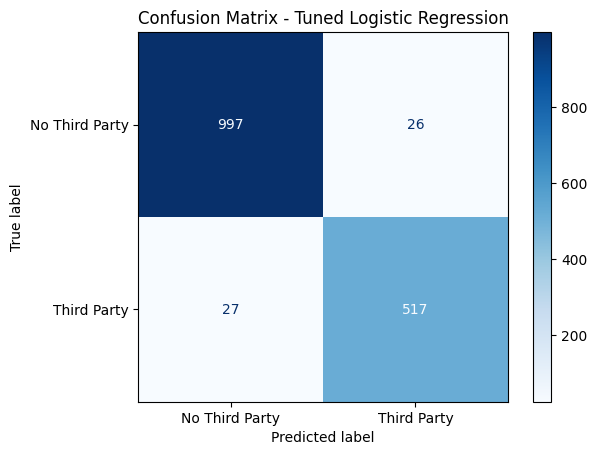

In [57]:
# Generate confusion matrix
cm = confusion_matrix(y, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Third Party", "Third Party"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.savefig("confusion_matrix_tuned_logreg.png", dpi=300, bbox_inches='tight')  # Save figure
plt.show()